In [1]:
import astropy as ap
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import os

from astropy import units as u
from astropy import constants as apc
from time import time

os.environ['CUPY_DUMP_CUDA_SOURCE_ON_ERROR'] = '1'

In [98]:
G = apc.G.to(u.kpc**3 / u.yr**2 / u.solMass)  # 4.4985e-24
G_flt = float(G * u.yr**2 * u.solMass / u.kpc**3)
N = 4
N_blocks = 1
N_threads = 4
dt = 1e3


milky_way_potential = cp.RawKernel(r'''
extern "C" __global__
void milky_way_potential(const double q[][6], double q_dot[][6]) {
    double nucl_m = 1.71e9;
    double nucl_a = 0.07;
    double bulge_m = 5e9;
    double bulge_a = 1.;
    double disk_m = 6.8e10;
    double disk_a = 3.;
    double disk_b = 0.28;
    double halo_m = 5.4e11;
    double halo_a = 15.62;
    double G = %s;
    
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    if (i >= %d)
        return;
    
    double r = sqrt(q[i][0]*q[i][0] + q[i][1]*q[i][1] + q[i][2]*q[i][2]);
    double sqrtz = sqrt(q[i][2]*q[i][2] + disk_b*disk_b);
    double zd = disk_a + sqrtz;
    double tmp = G * disk_m * pow(q[i][0]*q[i][0] + q[i][1]*q[i][1] + zd*zd, -1.5);

    for (int j = 0; j < 3; j++) {
        q_dot[i][j] = q[i][j+3];
    
        q_dot[i][j+3] = -G * nucl_m / (r * (r+nucl_a) * (r+nucl_a)) * q[i][j];
        q_dot[i][j+3] -= G * bulge_m / (r * (r+bulge_a) * (r+bulge_a)) * q[i][j];
        q_dot[i][j+3] -= G * halo_m * (log(1 + r/halo_a) - r/(r + halo_a)) / (r*r*r) * q[i][j];

        q_dot[i][j+3] -= tmp * q[i][j] * ( j==2 ? (1 + disk_a/sqrtz) : 1);
    }
}
''' % (G_flt, N), 'milky_way_potential')


n_body_potential = cp.RawKernel(r'''
extern "C" __global__
void n_body_potential(const double m[], const double q[][6], double q_dot[][6]) {
    double G = %s;
    
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    int n = blockDim.y * blockIdx.y + threadIdx.y;
    
    if (i >= %d or n >= %d)
        return;
    
    if (n == i)
        return;

    double r2 = 0;
    for (int k = 0; k < 3; k++)
        r2 += (q[i][k] - q[n][k]) * (q[i][k] - q[n][k]);

    for (int k = 0; k < 3; k++)
        q_dot[i][k+3] -= G * m[n] * (q[i][k] - q[n][k]) / (r2 * sqrt(r2));
}
''' % (G_flt, N, N), 'n_body_potential')


def time_derivative(m, q, q_dot):
    milky_way_potential((N_blocks,), (N_threads,), (q, q_dot))
    n_body_potential((N_blocks, N_blocks), (N_threads, N_threads), (m, q, q_dot))
    
    
def time_step(m, q):
    # first iteration prediction
    q_dot1 = cp.zeros_like(q)
    time_derivative(m, q, q_dot1)
    q_tmp = q + dt * q_dot1
    
    # second iteration
    q_dot2 = cp.zeros_like(q)
    time_derivative(m, q_tmp, q_dot2)
    
    return q + dt/2 * (q_dot1 + q_dot2)


def print_time(start_time, loop_i, loop_length):
    progress = loop_i/loop_length
    est_time = (1/progress - 1) * (time() - start_time)
    print(f'Progress: {100*progress:.0f}%\t Estimated time left: {est_time:.0f}s', end='\t ')
    print('|'*int(progress*50 - 1) + '\\' + '_'*int(50 - progress*50))

In [97]:
masses = cp.array([100., 20., 0.7, 4.])
q_init = cp.array([[-3.09, 2.00, 0.01, -1e-12, -2.00e-7, 1e-7],
                   [-3.04, 2.05, 0.03, -1e-12, -2.00e-7, 1e-7],
                   [-3.03, 2.16, 0.08, -1e-12, -2.00e-7, 1e-7],
                   [-3.00, 2.02, 0.07, -1e-12, -2.00e-7, 1e-7]
                  ])

T = 5e8
N_pts = int(T/dt)
ts = np.arange(0, T, dt)
qs = cp.zeros((N_pts, N, 6))
qs[0] = q_init
q = q_init

start_time = time()
for i in range(N_pts):
    q = time_step(masses, q)
    qs[i] = q
    
    if i % 10000 == 1:
        print_time(start_time, i, N_pts)

print(f'Total time: {time() - start_time:.0f}s')
qs = cp.asnumpy(qs)

Progress: 0%	 Estimated time left: 271s	 \_________________________________________________
Progress: 2%	 Estimated time left: 64s	 \________________________________________________
Progress: 4%	 Estimated time left: 61s	 |\_______________________________________________
Progress: 6%	 Estimated time left: 60s	 ||\______________________________________________
Progress: 8%	 Estimated time left: 58s	 |||\_____________________________________________
Progress: 10%	 Estimated time left: 63s	 ||||\____________________________________________
Progress: 12%	 Estimated time left: 63s	 |||||\___________________________________________
Progress: 14%	 Estimated time left: 61s	 ||||||\__________________________________________
Progress: 16%	 Estimated time left: 58s	 |||||||\_________________________________________
Progress: 18%	 Estimated time left: 56s	 ||||||||\________________________________________
Progress: 20%	 Estimated time left: 55s	 |||||||||\_______________________________________
Pr

Text(0, 0.5, 'y')

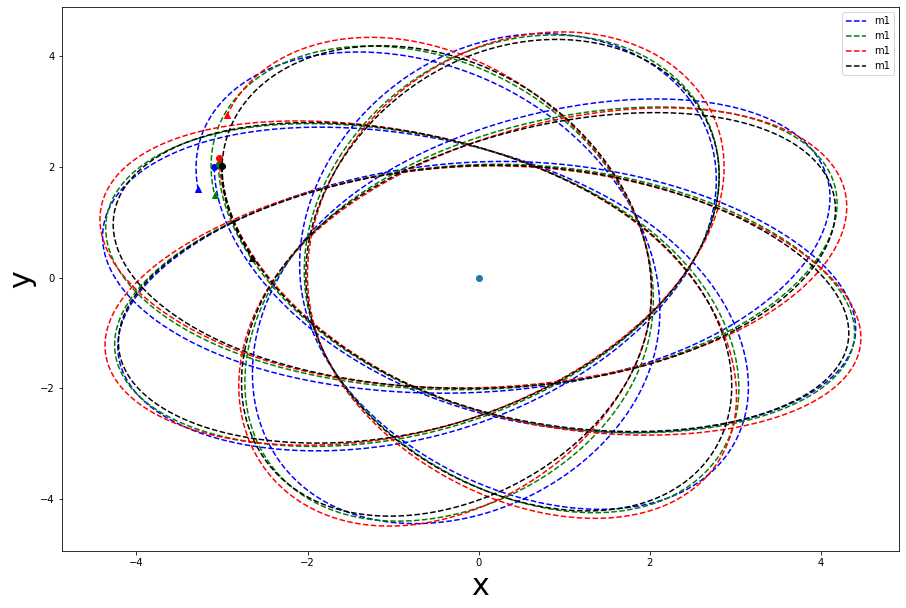

In [102]:
colors = ['b', 'g', 'r', 'k']

plt.figure(figsize=(15, 10))
for i in range(4):
    plt.plot(qs[:, i, 0], qs[:, i, 1], '--', color=colors[i], label='m1')
    plt.plot(qs[0, i, 0], qs[0, i, 1], 'o', color=colors[i])
    plt.plot(qs[-1, i, 0], qs[-1, i, 1], '^', color=colors[i])
    
plt.scatter(0, 0)
plt.legend()
plt.xlabel('x', fontsize=30)
plt.ylabel('y', fontsize=30)

Text(0, 0.5, 'z')

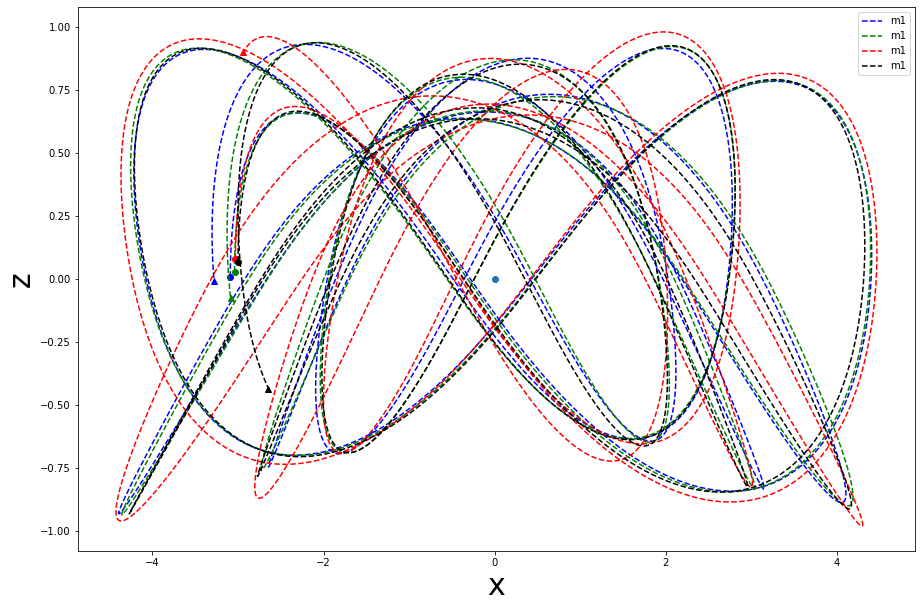

In [103]:
plt.figure(figsize=(15, 10))
for i in range(4):
    plt.plot(qs[:, i, 0], qs[:, i, 2], '--', color=colors[i], label='m1')
    plt.plot(qs[0, i, 0], qs[0, i, 2], 'o', color=colors[i])
    plt.plot(qs[-1, i, 0], qs[-1, i, 2], '^', color=colors[i])
    
plt.scatter(0, 0)
plt.legend()
plt.xlabel('x', fontsize=30)
plt.ylabel('z', fontsize=30)

Text(0, 0.5, 'z')

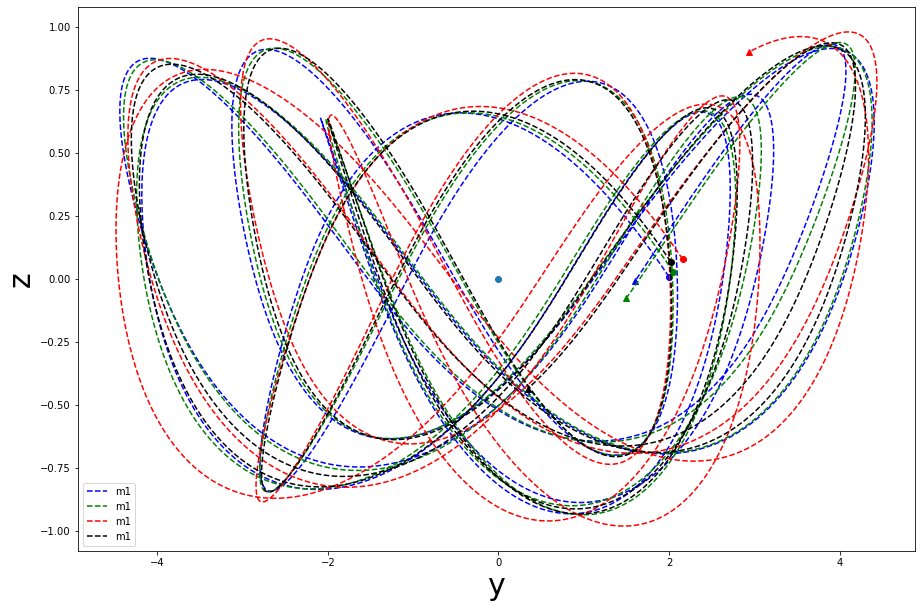

In [104]:
plt.figure(figsize=(15, 10))
for i in range(4):
    plt.plot(qs[:, i, 1], qs[:, i, 2], '--', color=colors[i], label='m1')
    plt.plot(qs[0, i, 1], qs[0, i, 2], 'o', color=colors[i])
    plt.plot(qs[-1, i, 1], qs[-1, i, 2], '^', color=colors[i])
    
plt.scatter(0, 0)
plt.legend()
plt.xlabel('y', fontsize=30)
plt.ylabel('z', fontsize=30)

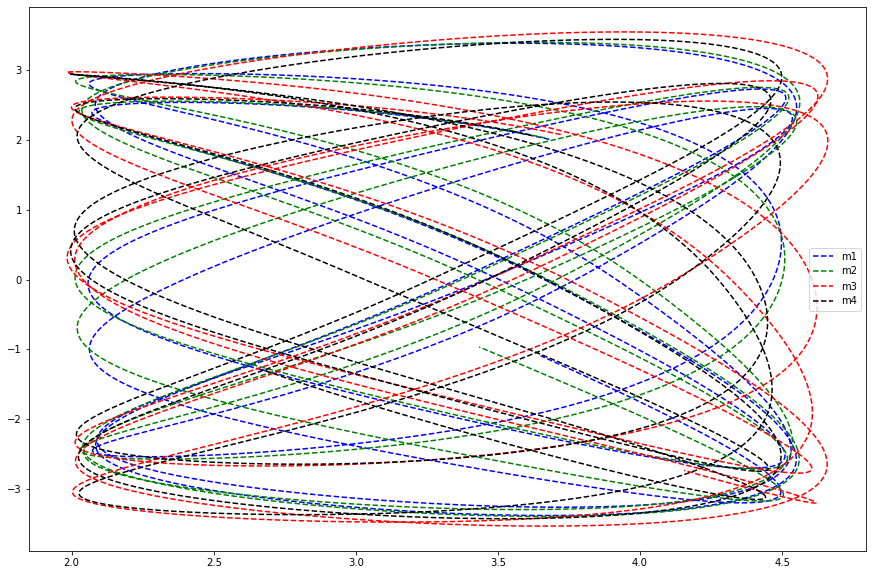

In [93]:
rhos = np.sqrt(qs[:, :, 0]**2 + qs[:, :, 1]**2)
plt.figure(figsize=(15, 10))
plt.plot(rhos[:, 0], zs[:, 0], 'b--', label='m1')
plt.plot(rhos[:, 1], zs[:, 1], 'g--', label='m2')
plt.plot(rhos[:, 2], zs[:, 2], 'r--', label='m3')
plt.plot(rhos[:, 3], zs[:, 3], 'k--', label='m4')
plt.scatter(0, 0)
plt.legend()

In [75]:
qs_sync = qs[:, :, :]

In [76]:
qs_sync - qs_nosync

array([[[0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.]],

       [[0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.]],

       [[0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.]],

       ...,

       [[0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.]],

       [[0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.]],

       [[0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.]]])

In [17]:
q_init

array([[-1.e+00,  2.e+00, -3.e+00,  0.e+00, -8.e+08,  0.e+00],
       [-2.e+00, -3.e+00,  1.e+00,  3.e-08,  1.e-07, -4.e-08],
       [-1.e+00, -3.e+00, -2.e+00,  8.e-08,  3.e-08, -3.e-07],
       [-3.e+00,  2.e+00,  2.e+00,  0.e+00, -2.e-07,  1.e-07]])